In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Buat folder untuk menyimpan parameter terbaik
out_dir = '/kaggle/working/outputs'
os.makedirs(out_dir, exist_ok=True)
print("Setup Random Search Selesai!")

2026-06-09 20:41:32.244473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781037692.469381      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781037692.529097      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781037693.050110      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781037693.050157      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781037693.050160      23 computation_placer.cc:177] computation placer alr

Setup Random Search Selesai!


In [ ]:
train_path = '/kaggle/input/notebooks/fauzanrasendriya/01-data-preprocessing-eda/opstat_1/train.csv'
val_path = '/kaggle/input/notebooks/fauzanrasendriya/01-data-preprocessing-eda/opstat_1/val.csv'

df_train = pd.read_csv(train_path, parse_dates=['Tanggal'], index_col='Tanggal')
df_val = pd.read_csv(val_path, parse_dates=['Tanggal'], index_col='Tanggal')

# Gabungkan data untuk Cross Validation
df_cv = pd.concat([df_train, df_val])

# Normalisasi Data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_cv[['Y']].values)

print(f"Total data untuk Sliding Window CV: {len(scaled_data)} hari.")

Total data untuk Sliding Window CV: 3615 hari.


In [3]:
def create_sequences(dataset, seq_len):
    X, y = [], []
    for i in range(len(dataset) - seq_len):
        X.append(dataset[i:(i + seq_len), 0])
        y.append(dataset[i + seq_len, 0])
    return np.array(X), np.array(y)

def build_lstm(seq_len, hidden_size, num_layers, lr, dropout):
    model = Sequential()
    # Layer 1
    model.add(LSTM(hidden_size, return_sequences=(num_layers > 1), input_shape=(seq_len, 1)))
    model.add(Dropout(dropout))
    
    # Tambahan Layer jika num_layers > 1
    for i in range(1, num_layers):
        model.add(LSTM(hidden_size, return_sequences=(i < num_layers - 1)))
        model.add(Dropout(dropout))
        
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [4]:
# Setup Sliding Window 
batas_hari_latih = 500 
tscv = TimeSeriesSplit(n_splits=3, max_train_size=batas_hari_latih)

# Budget Evaluasi (Sama dengan CPSO: 20 partikel x 30 iterasi = 600)
n_iter = 600

# Variabel untuk melacak parameter terbaik
best_rmse = float('inf')
best_hp = {}

# Menyimpan riwayat error untuk visualisasi
history_rmse = []

print("================================================================")
print(f"MEMULAI RANDOM SEARCH DENGAN SLIDING WINDOW CV")
print(f"Total Evaluasi: {n_iter} | Folds: {tscv.n_splits}")
print("================================================================")

for i in range(n_iter):
    # 1. Menghasilkan Hyperparameter Acak (Sesuai batas/bounds CPSO)
    seq_len     = random.randint(10, 50)
    hidden_size = random.randint(50, 300)
    num_layers  = random.randint(1, 3)
    lr          = random.uniform(0.0001, 0.0100)
    dropout     = random.uniform(0.0, 0.5)
    batch_size  = random.randint(16, 128)
    epochs      = random.randint(30, 100)
    
    # 2. Buat Sekuens Data
    X, y = create_sequences(scaled_data, seq_len)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    fold_rmse = []
    
    # 3. Evaluasi Sliding Window
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model = build_lstm(seq_len, hidden_size, num_layers, lr, dropout)
        model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=0)
        
        predictions = model.predict(X_test, verbose=0)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        fold_rmse.append(rmse)
    
    # 4. Hitung Rata-rata RMSE dari 3 fold
    avg_rmse = np.mean(fold_rmse)
    history_rmse.append(avg_rmse)
    
    # 5. Cek apakah ini rekor terbaik yang baru
    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_hp = {
            "seq_len": seq_len,
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "lr": lr,
            "dropout": dropout,
            "batch_size": batch_size,
            "epochs": epochs
        }
        print(f"[*] REKOR BARU! Iterasi {i+1} | RMSE: {best_rmse:.5f} | seq: {seq_len}, hid: {hidden_size}")
    
    # Print progress berkala agar kita tahu modelnya berjalan
    if (i + 1) % 50 == 0:
        print(f"--- Progress: {i+1}/{n_iter} evaluasi selesai ---")

MEMULAI RANDOM SEARCH DENGAN SLIDING WINDOW CV
Total Evaluasi: 600 | Folds: 3


I0000 00:00:1781037706.700504      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781037706.706939      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1781037709.860065      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using

[*] REKOR BARU! Iterasi 1 | RMSE: 0.02613 | seq: 50, hid: 78


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

[*] REKOR BARU! Iterasi 3 | RMSE: 0.02469 | seq: 33, hid: 197


...

--- Progress: 550/600 evaluasi selesai ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

[*] REKOR BARU! Iterasi 563 | RMSE: 0.01663 | seq: 25, hid: 94


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

--- Progress: 600/600 evaluasi selesai ---


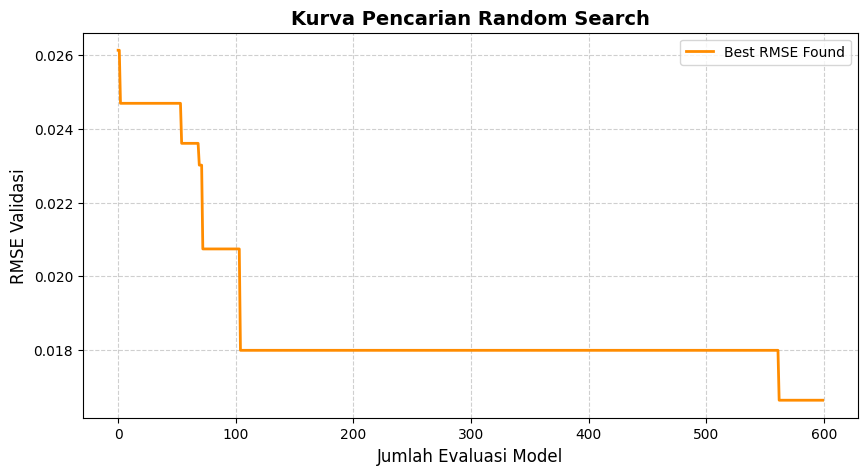

RINGKASAN RANDOM SEARCH (SLIDING WINDOW CV)
Best RMSE_CV (Normalized): 0.016634
Hyperparameter Optimal:
  - seq_len        : 25
  - hidden_size    : 94
  - num_layers     : 1
  - lr             : 0.005396353482725237
  - dropout        : 0.06302731382395105
  - batch_size     : 34
  - epochs         : 93

Hasil Random Search berhasil disimpan ke: /kaggle/working/outputs/rs_sliding_results.json


In [5]:
# Plot perbandingan penemuan nilai optimal dari waktu ke waktu
plt.figure(figsize=(10, 5))
# np.minimum.accumulate akan menyimpan nilai terkecil yang ditemukan sejauh ini
plt.plot(np.minimum.accumulate(history_rmse), color='darkorange', linewidth=2, label='Best RMSE Found')
plt.title('Kurva Pencarian Random Search', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Evaluasi Model', fontsize=12)
plt.ylabel('RMSE Validasi', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("============================================================")
print("RINGKASAN RANDOM SEARCH (SLIDING WINDOW CV)")
print("============================================================")
print(f"Best RMSE_CV (Normalized): {best_rmse:.6f}")
print("Hyperparameter Optimal:")
for k, v in best_hp.items():
    print(f"  - {k:<15}: {v}")

# Simpan ke JSON
results_path = os.path.join(out_dir, "rs_sliding_results.json")
with open(results_path, "w") as f:
    json.dump(best_hp, f, indent=4)

print(f"\nHasil Random Search berhasil disimpan ke: {results_path}")